In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("insurance.csv")

<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [7]:
# convert categorical to numeric
df=pd.get_dummies(df, drop_first=True)

In [8]:
df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [10]:
X=df.drop("charges", axis=1).values
y=df["charges"].values

In [14]:
X

array([[19, 27.9, 0, ..., False, False, True],
       [18, 33.77, 1, ..., False, True, False],
       [28, 33.0, 3, ..., False, True, False],
       ...,
       [18, 36.85, 0, ..., False, True, False],
       [21, 25.8, 0, ..., False, False, True],
       [61, 29.07, 0, ..., True, False, False]],
      shape=(1338, 8), dtype=object)

In [15]:
y

array([16884.924 ,  1725.5523,  4449.462 , ...,  1629.8335,  2007.945 ,
       29141.3603], shape=(1338,))

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
# add bias

X_train=np.c_[np.ones(X_train.shape[0]), X_train]
X_test=np.c_[np.ones(X_test.shape[0]), X_test]

# Initialise Parameters

In [30]:
theta=np.zeros(X_train.shape[1])
lr=0.01
epochs=300

In [29]:
theta

array([0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [31]:
import numpy as np

def gradient_descent(X, y, theta, lr, epochs):
    m = len(y)
    cost_history = []

    for _ in range(epochs):
        predictions = X.dot(theta)
        errors = predictions - y

        slope = (1/m) * X.T.dot(errors)
        theta = theta - lr * slope

        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)

    return theta, cost_history

In [25]:
n_samples, n_features = X_train.shape

w = np.zeros(n_features)
b = 0

learning_rate = 0.01
epochs = 300

In [26]:
cost_history = []

for i in range(epochs):
    
    y_pred = np.dot(X_train, w) + b
    
    dw = (-2/n_samples) * np.dot(X_train.T, (y_train - y_pred))
    db = (-2/n_samples) * np.sum(y_train - y_pred)
    
    w -= learning_rate * dw
    b -= learning_rate * db
    
    cost = np.mean((y_train - y_pred) ** 2)
    cost_history.append(cost)

print("Final weights:", w)
print("Final bias:", b)

UFuncTypeError: Cannot cast ufunc 'subtract' output from dtype('O') to dtype('float64') with casting rule 'same_kind'

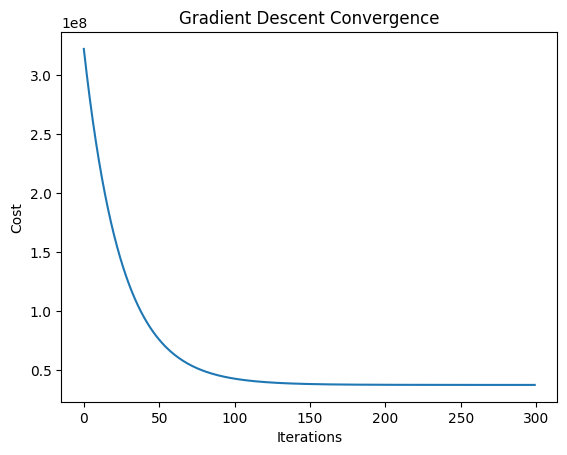

In [18]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()

In [19]:
y_test_pred = np.dot(X_test, w) + b

mse = np.mean((y_test - y_test_pred) ** 2)
print("Test MSE:", mse)

Test MSE: 33659415.09543842


In [20]:
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum((y_test - y_test_pred)**2)

r2 = 1 - (ss_residual / ss_total)
print("R2 Score:", r2)

R2 Score: 0.7831904018022717
